In [1]:
!pip install shapely

# Clasificación de Lugares con Clustering K-Means

Este notebook clasifica lugares basándose en patrones de comportamiento de visitantes usando KMeans clustering.

## 1. Configuración e Importaciones

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from datetime import datetime
import os
import warnings
warnings.filterwarnings('ignore')

# Clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Evaluation metrics
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score
)

# Visualization settings
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 8)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## 2. Configuración

In [3]:
# File paths
DATA_FILE = '../datos/filtered_amss/sv_12_2023_location_features_amss.csv'
OUTPUT_DIR = 'results'
MODELS_DIR = os.path.join(OUTPUT_DIR, 'models')

# Clustering parameters
K_RANGE = range(2, 21)  # Test clusters from 2 to 20
OPTIMAL_K = None  # Will be determined by análisis
RANDOM_STATE = 42

# Create directories
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print(f"Configuration:")
print(f"  Data file: {DATA_FILE}")
print(f"  Output directory: {OUTPUT_DIR}")
print(f"  Testing K values: {min(K_RANGE)} to {max(K_RANGE)}")

Configuration:
  Data file: ../datos/filtered_amss/sv_12_2023_location_features_amss.csv
  Output directory: results
  Testing K values: 2 to 20


## 3. Load and Explore Data

In [4]:
# Load data
df = pd.read_csv(DATA_FILE)

print(f"Datos cargados: {len(df):,} lugares")
print(f"Características: {len(df.columns)} columns")
print(f"\nFirst few rows:")
df.head()

Datos cargados: 14,697 lugares
Características: 65 columns

First few rows:


,osm_id,clase,nombre,geometry_wkt,unique_visits_weekday,footfall_avg_per_day,unique_devices_count,unique_device_by_timeblock_morning,unique_device_by_timeblock_afternoon,unique_device_by_timeblock_evening,...,dwell_time_median,dwell_time_weekday_mean,dwell_time_weekend_mean,days_active,avg_visits_per_active_day,std_visits_per_day,weekend_to_weekday_ratio,morning_to_evening_ratio,repeat_to_unique_ratio,avg_visits_per_device
0,400846765,bank,Banco Industrial,"POLYGON ((-89.2383563 13.6947575, -89.238334 1...",12,1.714286,9,4,7,1,...,0.0,10.112500,NaN,7,4.000000,3.366502,0.000000,4.00,2.111111,3.111111
1,400002511,residential,Palo Alto,"POLYGON ((-89.2576736 13.7101421, -89.2571881 ...",17,1.411765,15,2,7,10,...,0.0,48.552941,41.983333,17,4.000000,4.415880,0.411765,0.20,3.533333,4.533333
2,556395539,parking,parking,"POLYGON ((-89.2001489 13.7046549, -89.200128 1...",12,1.300000,11,8,4,0,...,0.0,0.033333,0.000000,10,1.400000,0.699206,0.083333,NaN,0.272727,1.272727
3,664504345,grass,grass,"POLYGON ((-89.2407758 13.7197677, -89.2406638 ...",12,1.153846,14,4,8,2,...,0.0,0.000000,0.000000,13,1.153846,0.375534,0.250000,2.00,0.071429,1.071429
4,312566571,building,Fusal,"POLYGON ((-89.2578833 13.6617643, -89.2577445 ...",9,1.153846,14,5,6,4,...,0.0,0.000000,5.975000,13,1.769231,1.363442,0.666667,1.25,0.642857,1.642857


In [5]:
# Data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14697 entries, 0 to 14696
Data columns (total 65 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   osm_id                                14697 non-null  int64  
 1   clase                                 14697 non-null  object 
 2   nombre                                14697 non-null  object 
 3   geometry_wkt                          14697 non-null  object 
 4   unique_visits_weekday                 14697 non-null  int64  
 5   footfall_avg_per_day                  14697 non-null  float64
 6   unique_devices_count                  14697 non-null  int64  
 7   unique_device_by_timeblock_morning    14697 non-null  int64  
 8   unique_device_by_timeblock_afternoon  14697 non-null  int64  
 9   unique_device_by_timeblock_evening    14697 non-null  int64  
 10  recurrence_rate                       14697 non-null  float64
 11  avg_days_to_ret

In [6]:
# Basic statistics
df.describe()

,osm_id,unique_visits_weekday,footfall_avg_per_day,unique_devices_count,unique_device_by_timeblock_morning,unique_device_by_timeblock_afternoon,unique_device_by_timeblock_evening,recurrence_rate,avg_days_to_return,peak_hour_weekday,...,dwell_time_median,dwell_time_weekday_mean,dwell_time_weekend_mean,days_active,avg_visits_per_active_day,std_visits_per_day,weekend_to_weekday_ratio,morning_to_evening_ratio,repeat_to_unique_ratio,avg_visits_per_device
count,1.469700e+04,14697.000000,14697.000000,14697.000000,14697.000000,14697.000000,14697.000000,14697.000000,7701.000000,13647.000000,...,14697.000000,13647.000000,10701.000000,14697.000000,14697.000000,11853.000000,13647.000000,10471.000000,14697.000000,14697.000000
mean,6.224668e+08,24.119820,1.887879,20.646254,8.558345,9.489420,6.516024,0.176210,5.234868,12.088737,...,31.677321,57.720069,64.194746,9.859359,6.954064,4.290139,0.396788,1.458327,6.755399,7.755399
std,3.501758e+08,82.715842,3.781059,61.895489,25.638807,33.004959,22.074191,0.262436,4.072599,5.262740,...,148.023587,152.312041,165.353108,9.580307,44.013204,13.905101,0.515815,1.881264,41.539072,41.539072
min,2.792058e+06,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,3.956899e+08,1.000000,1.000000,2.000000,1.000000,1.000000,0.000000,0.000000,2.200000,8.000000,...,0.000000,0.000000,0.000000,2.000000,1.000000,0.447214,0.000000,0.500000,0.000000,1.000000
50%,4.249417e+08,5.000000,1.071429,4.000000,2.000000,2.000000,1.000000,0.055556,4.200000,12.000000,...,0.000000,0.837179,0.327778,6.000000,1.555556,1.154701,0.303030,1.000000,0.500000,1.500000
75%,9.841072e+08,16.000000,1.500000,14.000000,6.000000,6.000000,4.000000,0.250000,7.000000,16.000000,...,0.000000,31.500000,32.500877,16.000000,3.272727,3.383785,0.500000,1.916667,2.000000,3.000000
max,1.323271e+09,2711.000000,129.400000,1762.000000,732.000000,1127.000000,800.000000,1.000000,28.000000,23.000000,...,1411.850000,1350.172500,1402.497917,30.000000,2463.000000,465.370578,9.000000,29.000000,1857.000000,1858.000000


### Revisando total de visitas por locales

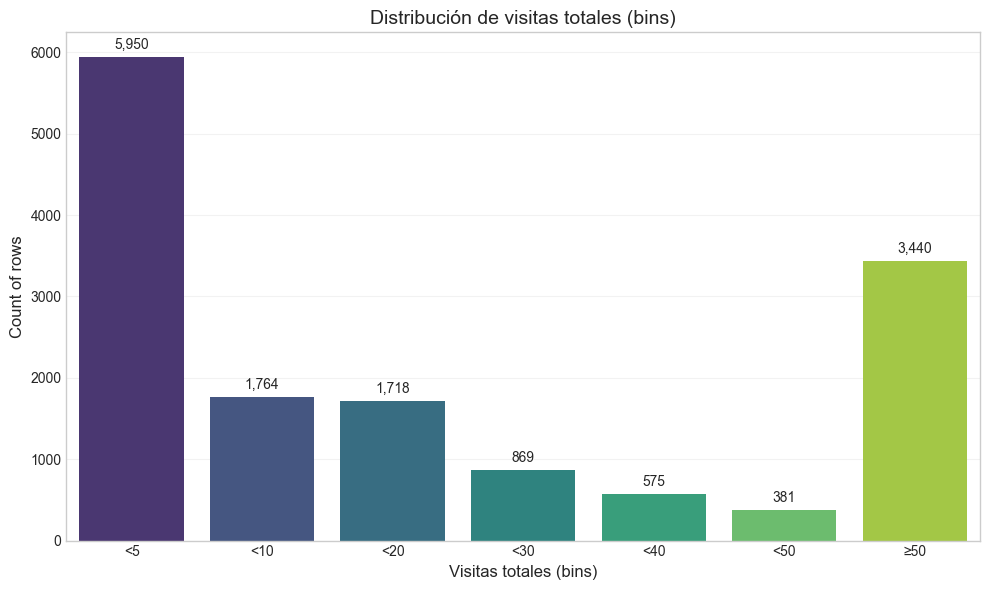

In [11]:
# Bar chart of visit totals in bins: 0,1,2,3,4,5,6-10,11-15,16-20,>20
col = 'visits_total' if 'visits_total' in df.columns else ('visit_totals' if 'visit_totals' in df.columns else None)
if col is None:
    raise KeyError("Column 'visits_total' or 'visit_totals' not found in df")

# Create bins: exact 0,1,2,3,4,5 then 6-10, 11-15, 16-20, then >20
vals = df[col].fillna(0).astype(int)
max_val = vals.max()
bins = [0, 5, 10, 20, 30, 40, 50, max_val+1]
labels = ['<5', '<10', '<20', '<30', '<40', '<50', '≥50']

binned = pd.cut(vals, bins=bins, labels=labels, include_lowest=True)
counts = binned.value_counts().reindex(labels).fillna(0).astype(int)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=counts.index, y=counts.values, palette='viridis', ax=ax)
ax.set_xlabel('Visitas totales (bins)', fontsize=12)
ax.set_ylabel('Count of rows', fontsize=12)
ax.set_title('Distribución de visitas totales (bins)', fontsize=14)
ax.grid(axis='y', alpha=0.25)

# Annotate counts on bars
for i, v in enumerate(counts.values):
    ax.text(i, v + max(counts.values)*0.01, f"{v:,}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/visits_total_binned_bar.png', dpi=200, bbox_inches='tight')
plt.show()

In [14]:
# Prepare clustering dataset
# Handle missing values and filter valid lugares

df_clustering = df.copy()

# Filter lugares with minimum activity (at least 5 unique visitors)
min_visitors = 10
df_clustering = df_clustering[df_clustering['visits_total'] >= min_visitors]

print(f"Places with >= {min_visitors} visitors: {len(df_clustering):,}")

Places with >= 10 visitors: 7,253


#### Revisando valores nulos en ubicaciones

In [15]:
# Check for missing values
missing = df_clustering.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    print("\nColumns with missing values:")
    print(missing)
    print(f"\nTotal lugares: {len(df_clustering)}")
else:
    print("\n✓ No missing values!")


Columns with missing values:
avg_days_to_return          940
morning_to_evening_ratio    549
peak_hour_weekend           415
dwell_time_weekend_mean     415
peak_hour_weekday            30
weekend_to_weekday_ratio     30
dwell_time_weekday_mean      30
std_visits_per_day           22
dwell_time_std               19
dtype: int64

Total lugares: 7253


### Imputando valores con 0 o con la mediana de acuerdo a los criterios por columna

In [16]:
# Definir columnas para imputar con 0
columns_impute_zero = [
    'avg_days_to_return',
    'morning_to_evening_ratio', 
    'dwell_time_weekend_mean',
    'weekend_to_weekday_ratio',
    'dwell_time_weekday_mean',
    'std_visits_per_day',
    'dwell_time_std'
]

# Definir columnas para imputar con mediana
columns_impute_median = [
    'peak_hour_weekday',
    'peak_hour_weekend'
]

for col in columns_impute_zero:
    if col in df_clustering.columns:
        df_clustering[col] = df_clustering[col].fillna(0)
        print(f"✓ Imputado con 0: {col}")

# Imputar con mediana
for col in columns_impute_median:
    if col in df_clustering.columns:
        median_value = df_clustering[col].median()
        df_clustering[col] = df_clustering[col].fillna(median_value)
        print(f"✓ Imputado con mediana ({median_value:.2f}): {col}")

# Verificar valores nulos restantes
missing_after = df_clustering.isnull().sum()
missing_after = missing_after[missing_after > 0]

if len(missing_after) > 0:
    print(f"\n⚠️  Columnas con valores nulos restantes:")
    print(missing_after)
else:
    print(f"\n✓ No hay valores nulos en df_clustering")

✓ Imputado con 0: avg_days_to_return
✓ Imputado con 0: morning_to_evening_ratio
✓ Imputado con 0: dwell_time_weekend_mean
✓ Imputado con 0: weekend_to_weekday_ratio
✓ Imputado con 0: dwell_time_weekday_mean
✓ Imputado con 0: std_visits_per_day
✓ Imputado con 0: dwell_time_std
✓ Imputado con mediana (12.00): peak_hour_weekday
✓ Imputado con mediana (11.00): peak_hour_weekend

✓ No hay valores nulos en df_clustering


## 4. Feature Engineering and Selección de variables

### analisis de correlación

In [26]:
exclude_columns = ['osm_id', 'clase', 'nombre', 'geometry_wkt', 'visits_by_hour_0', 'visits_by_hour_1', 'visits_by_hour_2',
       'visits_by_hour_3', 'visits_by_hour_4', 'visits_by_hour_5',
       'visits_by_hour_6', 'visits_by_hour_7', 'visits_by_hour_8',
       'visits_by_hour_9', 'visits_by_hour_10', 'visits_by_hour_11',
       'visits_by_hour_12', 'visits_by_hour_13', 'visits_by_hour_14',
       'visits_by_hour_15', 'visits_by_hour_16', 'visits_by_hour_17',
       'visits_by_hour_18', 'visits_by_hour_19', 'visits_by_hour_20',
       'visits_by_hour_21', 'visits_by_hour_22', 'visits_by_hour_23',
       'visits_by_day_0', 'visits_by_day_1', 'visits_by_day_2',
       'visits_by_day_3', 'visits_by_day_4', 'visits_by_day_5',
       'visits_by_day_6']

correlation_columns = [col for col in df_clustering.columns if col not in exclude_columns]


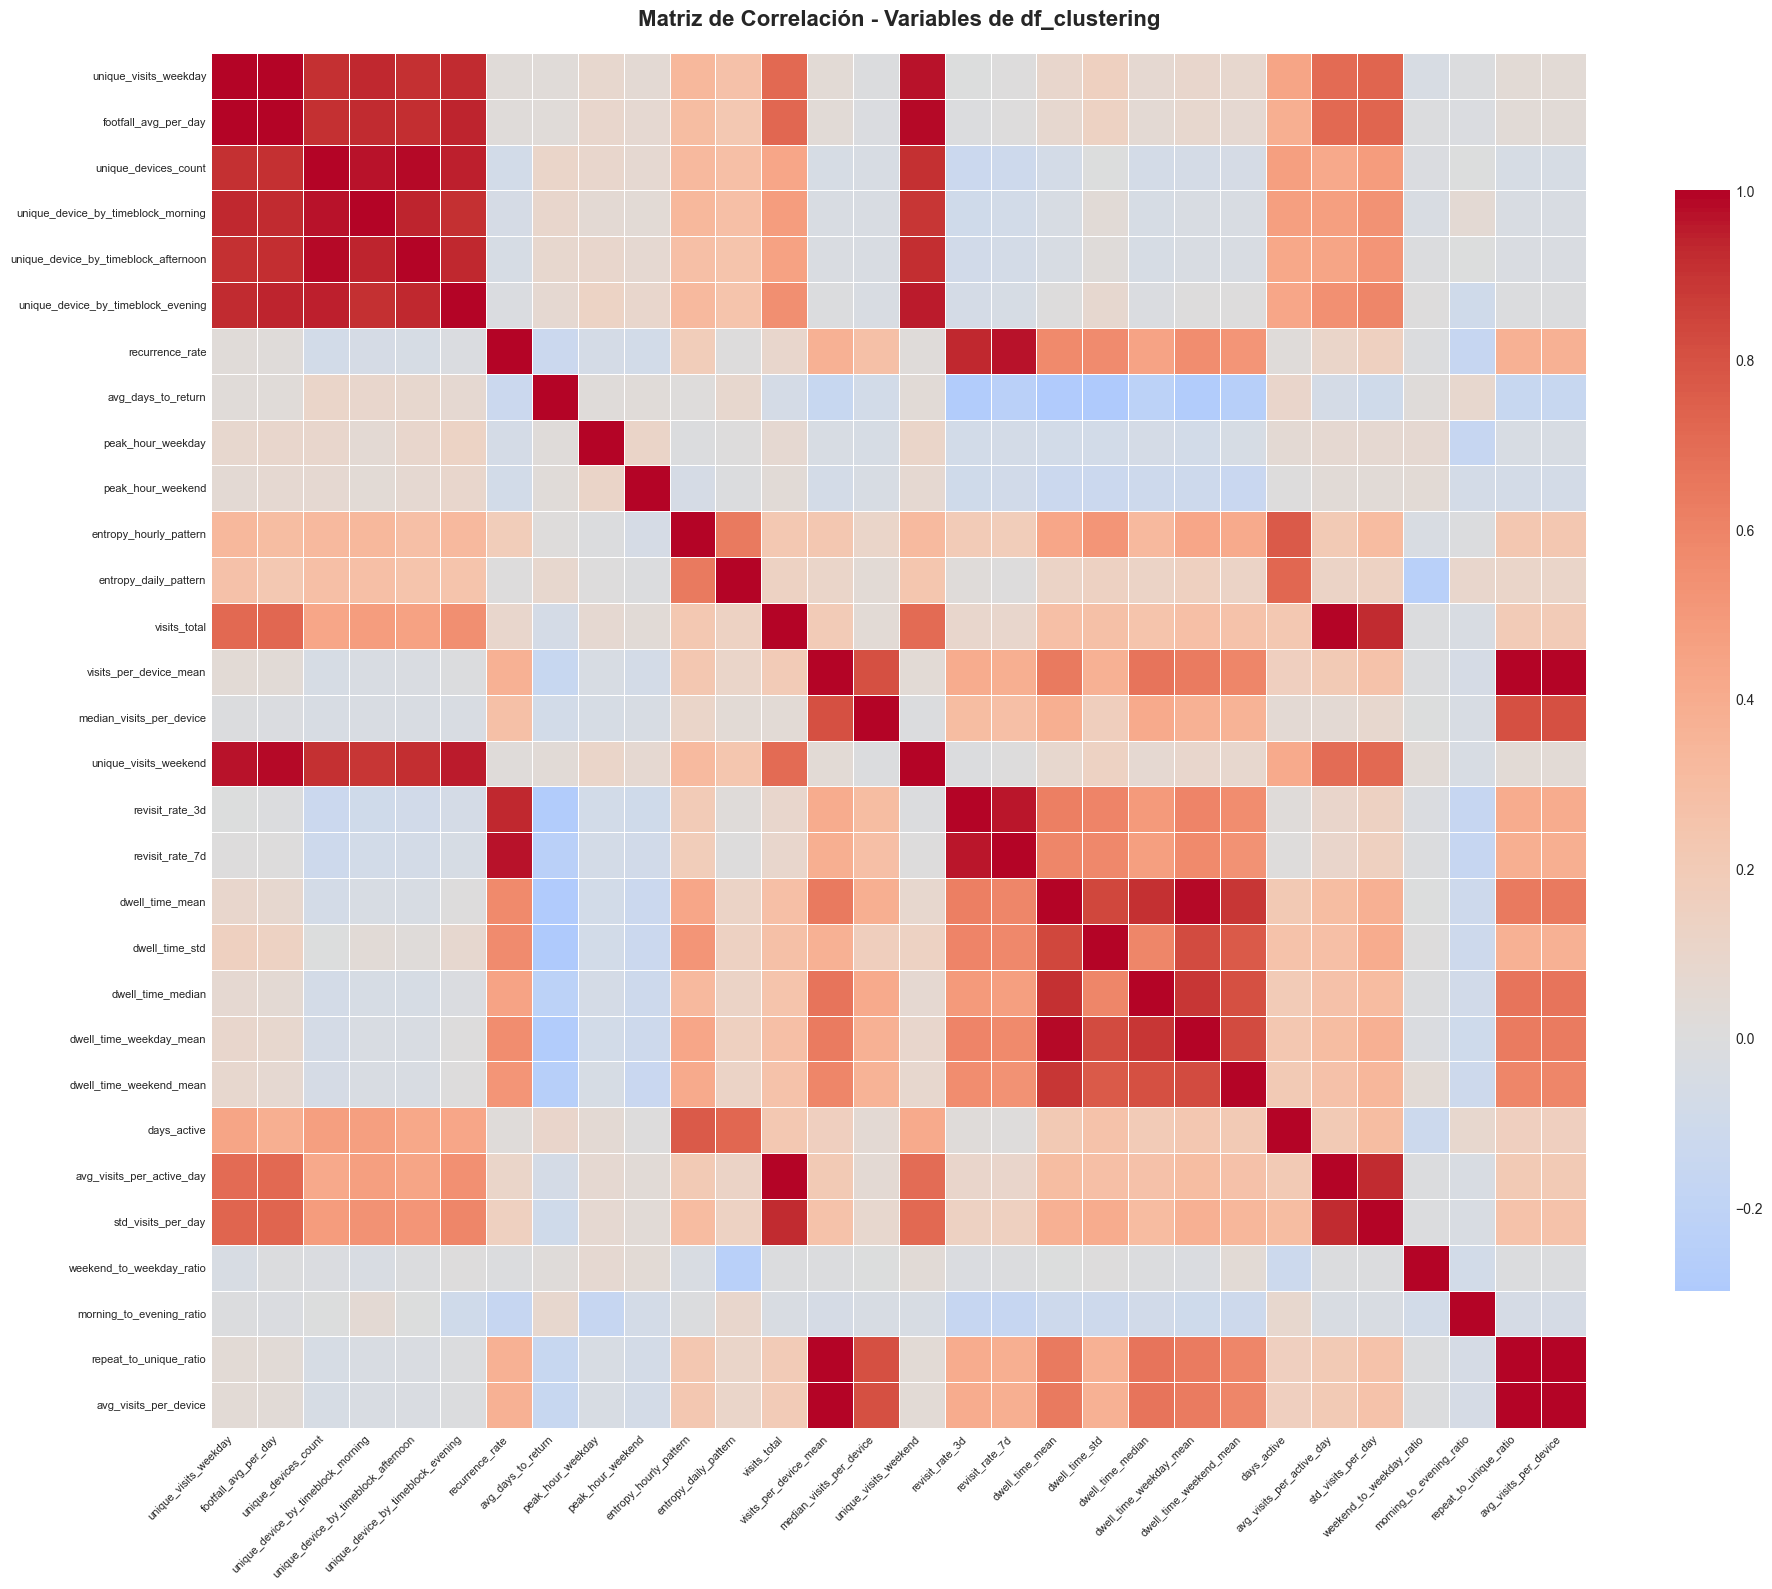

In [27]:
correlation_matrix = df_clustering[correlation_columns].corr()

plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, 
            annot=False, square=True, linewidths=0.5, 
            cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación - Variables de df_clustering', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('results/correlation_matrix_full.png', dpi=300, bbox_inches='tight')
plt.show()


In [23]:
print("\n" + "="*80)
print("PARES DE VARIABLES CON CORRELACIÓN > 0.8")
print("="*80)

high_corr_pairs = []
threshold = 0.8

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > threshold:
            var1 = correlation_matrix.columns[i]
            var2 = correlation_matrix.columns[j]
            high_corr_pairs.append({
                'variable_1': var1,
                'variable_2': var2,
                'correlation': corr_value
            })

# Crear DataFrame con los pares
df_high_corr = pd.DataFrame(high_corr_pairs)
df_high_corr = df_high_corr.sort_values('correlation', ascending=False, key=abs)

print(f"\nEncontrados {len(df_high_corr)} pares de variables con |correlación| > {threshold}")
print("\n")
print(df_high_corr.to_string(index=False))


PARES DE VARIABLES CON CORRELACIÓN > 0.8

Encontrados 41 pares de variables con |correlación| > 0.8


                          variable_1                           variable_2  correlation
              visits_per_device_mean                avg_visits_per_device     1.000000
              repeat_to_unique_ratio                avg_visits_per_device     1.000000
              visits_per_device_mean               repeat_to_unique_ratio     1.000000
                        visits_total            avg_visits_per_active_day     0.999081
               unique_visits_weekday                 footfall_avg_per_day     0.994884
                footfall_avg_per_day                unique_visits_weekend     0.983730
                unique_devices_count unique_device_by_timeblock_afternoon     0.981357
                     dwell_time_mean              dwell_time_weekday_mean     0.980636
                     recurrence_rate                      revisit_rate_7d     0.970865
                unique_devi

In [28]:
columns_high_corr = ['avg_visits_per_device','repeat_to_unique_ratio','avg_visits_per_active_day','footfall_avg_per_day','unique_device_by_timeblock_afternoon','dwell_time_weekday_mean','revisit_rate_7d','unique_device_by_timeblock_morning','unique_device_by_timeblock_evening','revisit_rate_3d','std_visits_per_day','dwell_time_weekend_mean','dwell_time_std','unique_visits_weekday','dwell_time_mean','visits_per_device_mean']

In [ ]:
correlation_columns_2 = [col for col in df.columns if col not in exclude_columns+columns_high_corr]

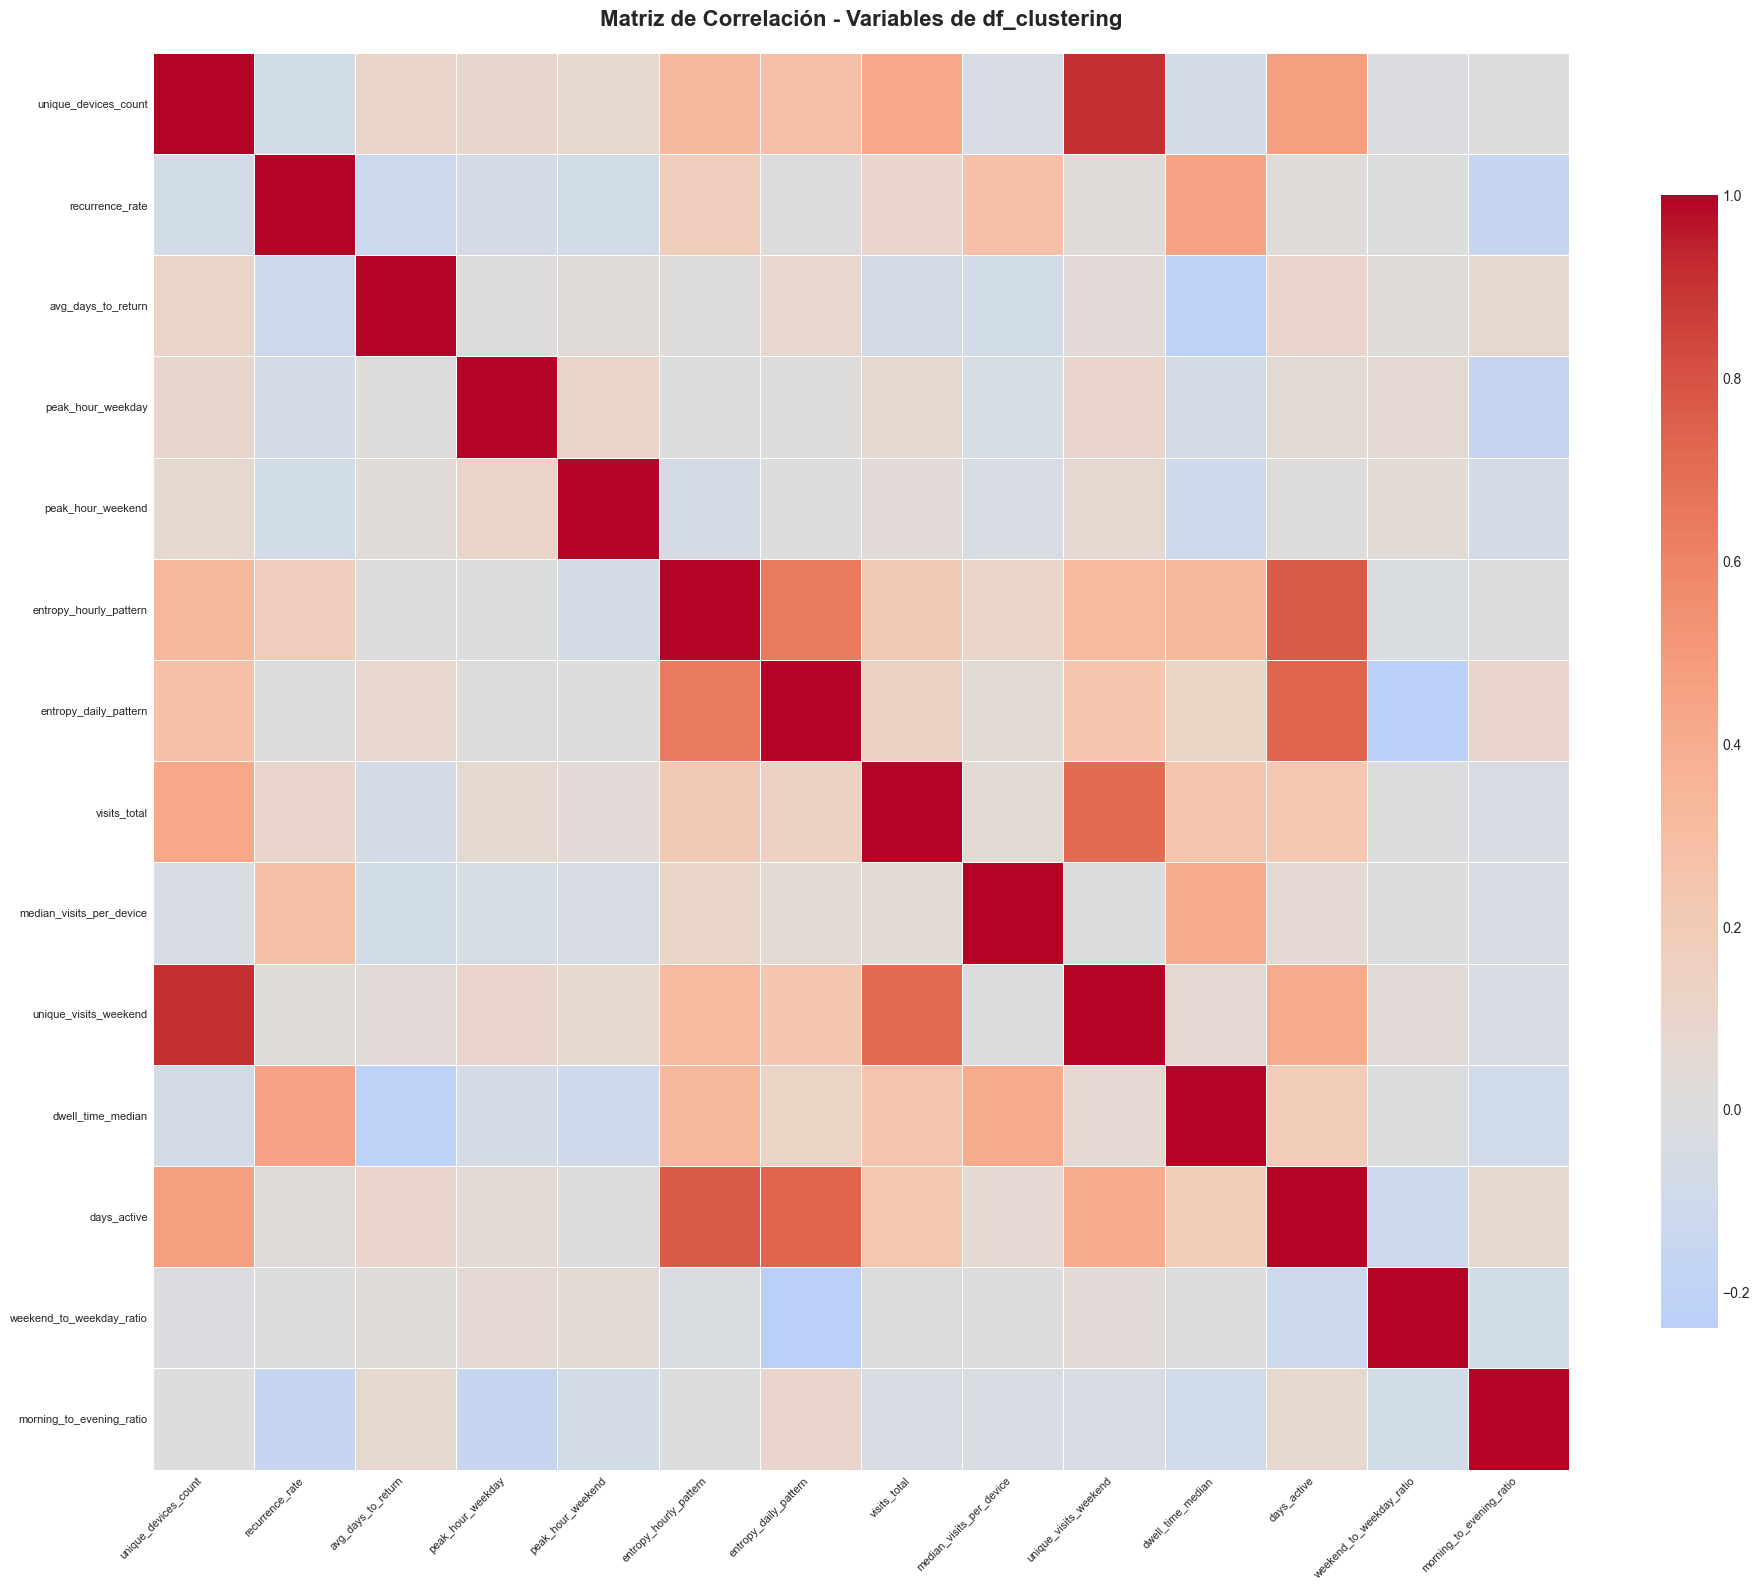

In [ ]:
correlation_matrix = df_clustering[correlation_columns_2].corr()

plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, 
            annot=False, square=True, linewidths=0.5, 
            cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación - Variables de df_clustering', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('results/correlation_matrix_full.png', dpi=300, bbox_inches='tight')
plt.show()


In [56]:
from shapely import wkt

def extract_centroid(geometry_wkt):
    """Extract centroid (lat, lon) from WKT geometry."""
    try:
        geom = wkt.loads(geometry_wkt)
        centroid = geom.centroid
        return centroid.y, centroid.x  # lat, lon
    except:
        return None, None

# Extract centroids
print("Extracting centroids from geometries...")
df_clustering[['latitude', 'longitude']] = df_clustering['geometry_wkt'].apply(
    lambda x: pd.Series(extract_centroid(x))
)

# Remove any invalid geometries
df_clustering = df_clustering.dropna(subset=['latitude', 'longitude'])

print(f"\n✓ {len(df_clustering):,} lugares with valid coordinates")
print(f"Latitude range: {df_clustering['latitude'].min():.6f} to {df_clustering['latitude'].max():.6f}")
print(f"Longitude range: {df_clustering['longitude'].min():.6f} to {df_clustering['longitude'].max():.6f}")

Extracting centroids from geometries...

✓ 7,253 lugares with valid coordinates
Latitude range: 13.550097 to 13.896838
Longitude range: -89.350379 to -89.098645


In [ ]:
CLUSTERING_FEATURES = correlation_columns_2

print(f"\nUsing {len(CLUSTERING_FEATURES)} features for clustering")

# Extract feature matrix
X = df_clustering[CLUSTERING_FEATURES].copy()

# Handle remaining missing values
print(f"\nMissing values before imputation:")
print(X.isnull().sum()[X.isnull().sum() > 0])


print(f"\n✓ Feature matrix prepared: {X.shape}")
print(f"  {X.shape[0]:,} lugares × {X.shape[1]} features")


Using 14 features for clustering

Missing values before imputation:
Series([], dtype: int64)

✓ Feature matrix prepared: (7253, 14)
  7,253 lugares × 14 features


## 5. Estandarización/Normalización

In [33]:
# Standardize features (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✓ Características standardized")
print(f"  Shape: {X_scaled.shape}")
print(f"  Mean: {X_scaled.mean():.6f}")
print(f"  Std: {X_scaled.std():.6f}")

# Show before/after standardization for one feature
sample_feature = CLUSTERING_FEATURES[0]
print(f"\nExample - {sample_feature}:")
print(f"  Before: mean={X[sample_feature].mean():.2f}, std={X[sample_feature].std():.2f}")
print(f"  After:  mean={X_scaled[:, 0].mean():.2f}, std={X_scaled[:, 0].std():.2f}")

✓ Características standardized
  Shape: (7253, 14)
  Mean: -0.000000
  Std: 1.000000

Example - unique_devices_count:
  Before: mean=39.29, std=84.10
  After:  mean=-0.00, std=1.00


## 6. Determine Optimal K - Elbow Method

In [65]:
import pandas as pd

print("Finding optimal number of clusters...")
print(f"Testing K from {min(K_RANGE)} to {max(K_RANGE)}")
print("This may take a few minutes...\n")

inertias = []
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

for k in K_RANGE:
    # Fit KMeans
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = kmeans.fit_predict(X_scaled)
    
    # Calculate metrics
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(X_scaled, labels))
    
    print(
        f"K={k:2d}: "
        f"Inertia={kmeans.inertia_:10.1f}, "
        f"Silhouette={silhouette_scores[-1]:.4f}, "
        f"Davies-Bouldin={davies_bouldin_scores[-1]:.4f}, "
        f"Calinski-Harabasz={calinski_harabasz_scores[-1]:.1f}"
    )

print("\n✓ Analysis complete!")

# Crear DataFrame con todos los resultados
results_df = pd.DataFrame({
    "k": list(K_RANGE),
    "inertia": inertias,
    "silhouette": silhouette_scores,
    "davies_bouldin": davies_bouldin_scores,
    "calinski_harabasz": calinski_harabasz_scores
})

Finding optimal number of clusters...
Testing K from 2 to 20
This may take a few minutes...

K= 2: Inertia=   87385.1, Silhouette=0.1691, Davies-Bouldin=2.0443, Calinski-Harabasz=1174.7
K= 3: Inertia=   78231.1, Silhouette=0.1693, Davies-Bouldin=1.6566, Calinski-Harabasz=1080.2
K= 4: Inertia=   70046.4, Silhouette=0.1777, Davies-Bouldin=1.5261, Calinski-Harabasz=1086.5
K= 5: Inertia=   65369.6, Silhouette=0.1303, Davies-Bouldin=1.7280, Calinski-Harabasz=1002.7
K= 6: Inertia=   61529.9, Silhouette=0.1548, Davies-Bouldin=1.6240, Calinski-Harabasz=942.5
K= 7: Inertia=   57794.7, Silhouette=0.1584, Davies-Bouldin=1.5027, Calinski-Harabasz=914.1
K= 8: Inertia=   54465.5, Silhouette=0.1655, Davies-Bouldin=1.4046, Calinski-Harabasz=894.6
K= 9: Inertia=   51373.0, Silhouette=0.1689, Davies-Bouldin=1.3854, Calinski-Harabasz=884.3
K=10: Inertia=   48501.5, Silhouette=0.1716, Davies-Bouldin=1.3559, Calinski-Harabasz=880.1
K=11: Inertia=   46000.4, Silhouette=0.1646, Davies-Bouldin=1.3754, Calinsk

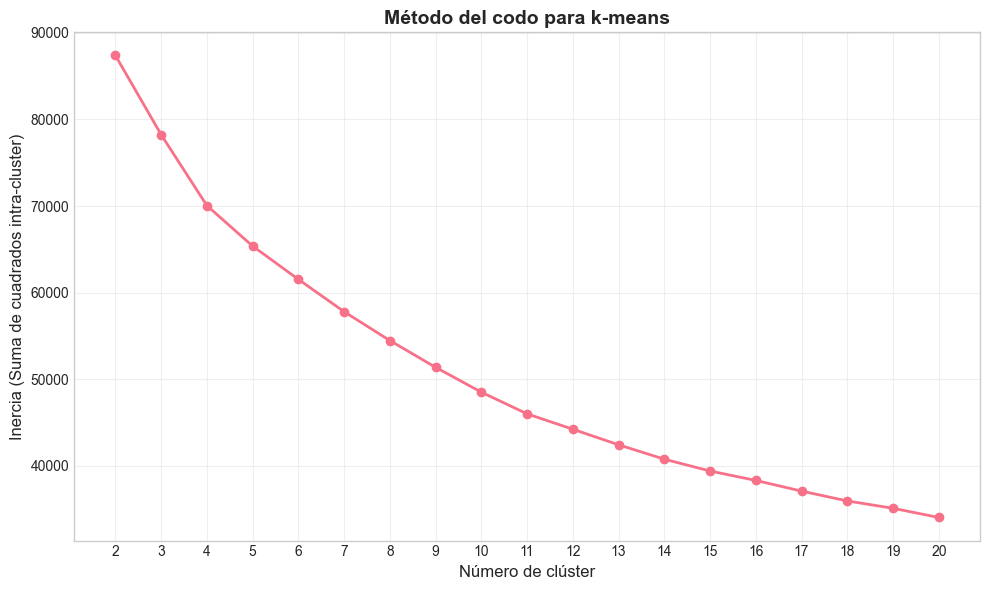

In [68]:
# Plot solo Elbow Method (Inertia)
plt.figure(figsize=(10, 6))
plt.plot(K_RANGE, inertias, marker='o', linewidth=2)
plt.xlabel('Número de clúster', fontsize=12)
plt.ylabel('Inercia (Suma de cuadrados intra-cluster)', fontsize=12)
plt.title('Método del codo para k-means', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_RANGE)
plt.tight_layout()
plt.show()

In [69]:
# Set optimal K (you can change this basado en análisis above)
OPTIMAL_K = 4

print(f"\n✓ Selected K = {OPTIMAL_K} for final clustering")


✓ Selected K = 4 for final clustering


## 7. Train Final KMeans Model

In [70]:
# Train final model with optimal K
print(f"Training final KMeans model with K={OPTIMAL_K}...")

kmeans_final = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=RANDOM_STATE,
    n_init=20,  # More initializations for better results
    max_iter=500
)

cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to dataframe
df_clustering['cluster'] = cluster_labels

print("\n✓ Clustering complete!")
print(f"  Inertia: {kmeans_final.inertia_:.2f}")
print(f"  Iterations: {kmeans_final.n_iter_}")

# Cluster distribution
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
print(f"\nCluster distribution:")
for cluster_id, count in cluster_counts.items():
    pct = 100 * count / len(cluster_labels)
    print(f"  Cluster {cluster_id}: {count:4d} lugares ({pct:5.2f}%)")

Training final KMeans model with K=4...

✓ Clustering complete!
  Inertia: 70046.44
  Iterations: 74

Cluster distribution:
  Cluster 0: 3341 lugares (46.06%)
  Cluster 1: 3469 lugares (47.83%)
  Cluster 2:   65 lugares ( 0.90%)
  Cluster 3:  378 lugares ( 5.21%)


## 8. Evaluación

In [71]:
# Calculate evaluation metrics
final_silhouette = silhouette_score(X_scaled, cluster_labels)
final_db = davies_bouldin_score(X_scaled, cluster_labels)
final_ch = calinski_harabasz_score(X_scaled, cluster_labels)

print("="*70)
print("FINAL MODEL EVALUATION")
print("="*70)
print(f"\nNumber of Clusters: {OPTIMAL_K}")
print(f"Number of Places: {len(cluster_labels):,}")
print(f"\nClustering Quality Metrics:")
print(f"  Silhouette Score:        {final_silhouette:.4f}")
if final_silhouette > 0.7:
    print(f"    → Excellent clustering quality")
elif final_silhouette > 0.5:
    print(f"    → Good clustering quality")
elif final_silhouette > 0.25:
    print(f"    → Acceptable clustering quality")
else:
    print(f"    → Weak clustering structure")

print(f"\n  Davies-Bouldin Index:    {final_db:.4f}")
print(f"    → Lower is better (measures separation)")

print(f"\n  Calinski-Harabasz Index: {final_ch:.2f}")
print(f"    → Higher is better (variance ratio)")
print("="*70)

FINAL MODEL EVALUATION

Number of Clusters: 4
Number of Places: 7,253

Clustering Quality Metrics:
  Silhouette Score:        0.1777
    → Weak clustering structure

  Davies-Bouldin Index:    1.5261
    → Lower is better (measures separation)

  Calinski-Harabasz Index: 1086.48
    → Higher is better (variance ratio)


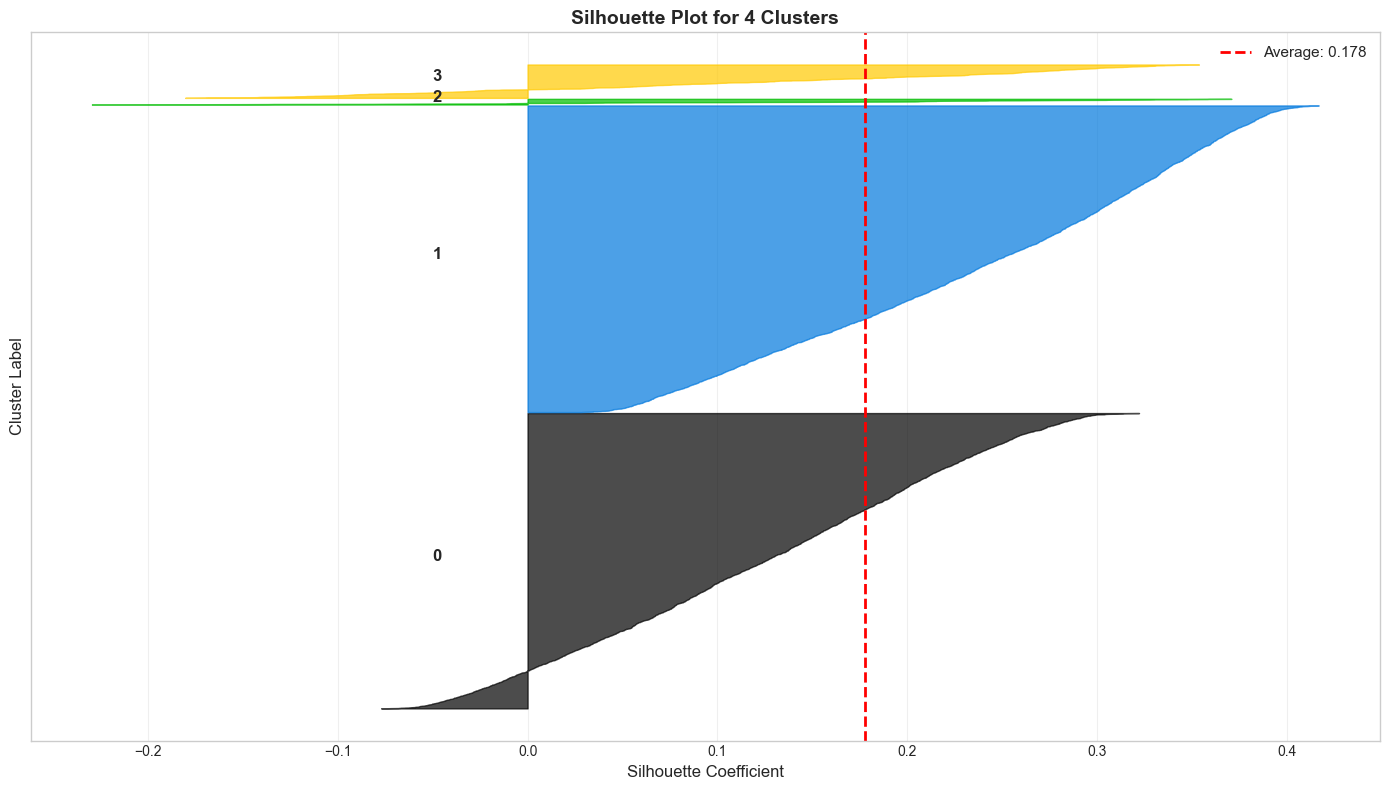

✓ Saved: results/kmeans_silhouette_análisis.png


In [72]:
# Silhouette análisis per cluster
silhouette_vals = silhouette_samples(X_scaled, cluster_labels)

fig, ax = plt.subplots(1, 1, figsize=(14, 8))

y_lower = 10
for i in range(OPTIMAL_K):
    cluster_silhouette_vals = silhouette_vals[cluster_labels == i]
    cluster_silhouette_vals.sort()

    size_cluster = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster

    color = plt.cm.nipy_spectral(float(i) / OPTIMAL_K)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals,
                     facecolor=color, edgecolor=color, alpha=0.7)

    ax.text(-0.05, y_lower + 0.5 * size_cluster, str(i), fontsize=12, fontweight='bold')
    y_lower = y_upper + 10

ax.set_xlabel('Silhouette Coefficient', fontsize=12)
ax.set_ylabel('Cluster Label', fontsize=12)
ax.set_title(f'Silhouette Plot for {OPTIMAL_K} Clusters', fontsize=14, fontweight='bold')
ax.axvline(x=final_silhouette, color="red", linestyle="--", linewidth=2,
          label=f'Average: {final_silhouette:.3f}')
ax.set_yticks([])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/kmeans_silhouette_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {OUTPUT_DIR}/kmeans_silhouette_análisis.png")

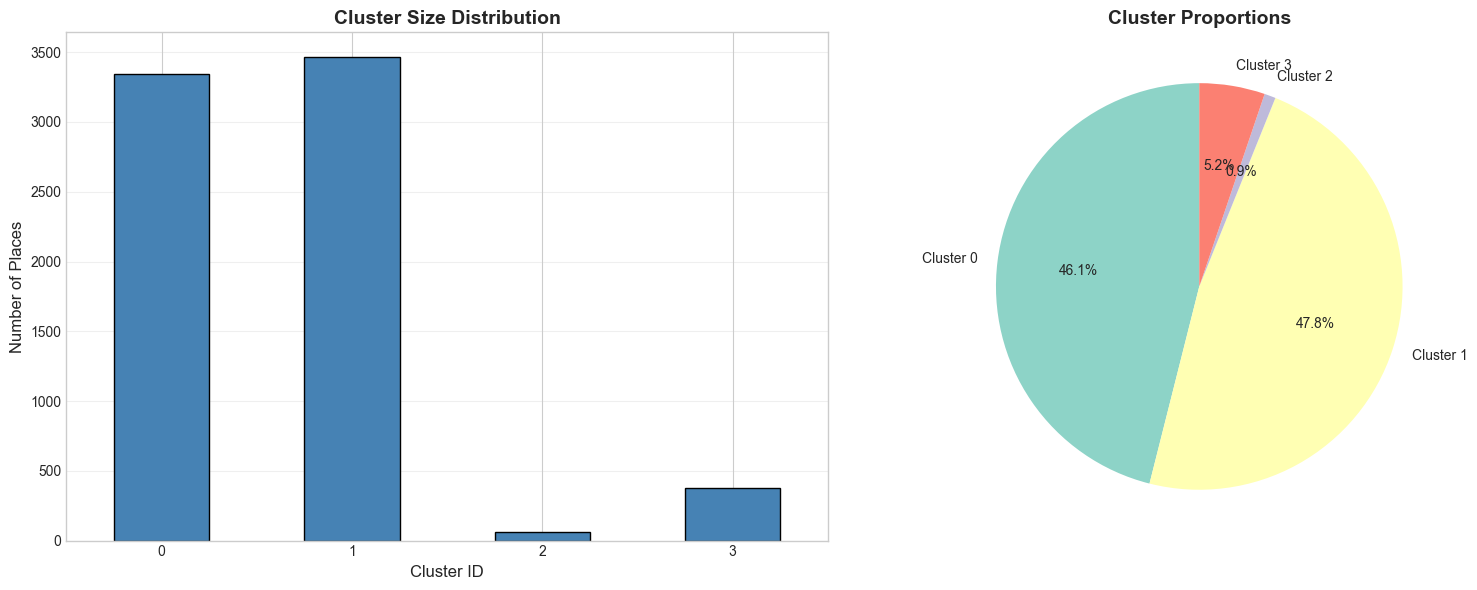

In [73]:
# Cluster size distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
cluster_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Cluster ID', fontsize=12)
axes[0].set_ylabel('Number of Places', fontsize=12)
axes[0].set_title('Cluster Size Distribution', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(True, alpha=0.3, axis='y')

# Pie chart
colors = plt.cm.Set3(range(OPTIMAL_K))
axes[1].pie(cluster_counts, labels=[f"Cluster {i}" for i in range(OPTIMAL_K)],
           autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Cluster Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Cluster Profiling

Analyze characteristics of each cluster to understand what types of lugares they represent.

In [74]:
# Calculate cluster profiles (mean values for each feature)
cluster_profiles = df_clustering.groupby('cluster')[CLUSTERING_FEATURES].mean()

# Also get median and std
cluster_median = df_clustering.groupby('cluster')[CLUSTERING_FEATURES].median()
cluster_std = df_clustering.groupby('cluster')[CLUSTERING_FEATURES].std()

print("Cluster profiles (mean values):")
cluster_profiles

Cluster profiles (mean values):


,unique_devices_count,recurrence_rate,avg_days_to_return,peak_hour_weekday,peak_hour_weekend,entropy_hourly_pattern,entropy_daily_pattern,visits_total,median_visits_per_device,unique_visits_weekend,dwell_time_median,days_active,weekend_to_weekday_ratio,morning_to_evening_ratio
cluster,,,,,,,,,,,,,,
0,9.000000,0.239848,3.660178,12.105058,11.139779,1.948297,1.242156,27.477402,2.495361,3.299611,14.939589,9.615684,0.483347,1.458509
1,61.522629,0.212845,5.151604,12.506198,11.317959,2.602803,1.655286,300.528106,1.700202,25.279908,19.483329,23.714039,0.382922,2.124547
2,582.630769,0.359997,3.679948,16.046154,13.692308,2.956181,1.772562,13061.138462,3.292308,399.584615,213.293590,30.000000,0.447336,1.047977
3,9.637566,0.723347,1.365695,10.624339,8.375661,2.961727,1.681475,1166.439153,75.431217,18.968254,804.641049,24.087302,0.406107,1.025645


In [75]:
cluster_profiles.to_clipboard()

## 10. Export Results

In [52]:
# Export clustered data
output_file = f'{OUTPUT_DIR}/kmeans_clustered_places.csv'
df_clustering.to_csv(output_file, index=False)
print(f"✓ Clustered lugares saved: {output_file}")

# Export cluster profiles
profiles_file = f'{OUTPUT_DIR}/kmeans_cluster_profiles.csv'
cluster_profiles.to_csv(profiles_file)
print(f"✓ Cluster profiles saved: {profiles_file}")

# Export evaluation metrics
metrics = {
    'optimal_k': OPTIMAL_K,
    'n_places': len(df_clustering),
    'n_features': len(CLUSTERING_FEATURES),
    'silhouette_score': final_silhouette,
    'davies_bouldin_score': final_db,
    'calinski_harabasz_score': final_ch,
    'inertia': kmeans_final.inertia_,
    'pca_variance_explained': sum(pca.explained_variance_ratio_)
}

metrics_file = f'{OUTPUT_DIR}/kmeans_evaluation_metrics.txt'
with open(metrics_file, 'w') as f:
    f.write("KMeans Clustering Evaluation Metrics\n")
    f.write("="*70 + "\n\n")
    for key, value in metrics.items():
        f.write(f"{key}: {value}\n")

print(f"✓ Evaluation metrics saved: {metrics_file}")

✓ Clustered lugares saved: results/kmeans_clustered_places.csv
✓ Cluster profiles saved: results/kmeans_cluster_profiles.csv
✓ Evaluation metrics saved: results/kmeans_evaluation_metrics.txt


## 11. Save Models with Pickle

In [53]:
# Create timestamp for versioning
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

print("="*70)
print("SAVING MODELS WITH PICKLE")
print("="*70)
print(f"\nTimestamp: {timestamp}")
print(f"Directory: {MODELS_DIR}/")

# Save KMeans model
model_file = os.path.join(MODELS_DIR, f'kmeans_model_{timestamp}.pkl')
with open(model_file, 'wb') as f:
    pickle.dump(kmeans_final, f)
print(f"\n✓ KMeans model saved: {os.path.basename(model_file)}")

# Save scaler
scaler_file = os.path.join(MODELS_DIR, f'scaler_{timestamp}.pkl')
with open(scaler_file, 'wb') as f:
    pickle.dump(scaler, f)
print(f"✓ Scaler saved: {os.path.basename(scaler_file)}")

# Save PCA model
pca_file = os.path.join(MODELS_DIR, f'pca_{timestamp}.pkl')
with open(pca_file, 'wb') as f:
    pickle.dump(pca, f)
print(f"✓ PCA model saved: {os.path.basename(pca_file)}")

# Save complete package
model_package = {
    'kmeans_model': kmeans_final,
    'scaler': scaler,
    'pca': pca,
    'cluster_profiles': cluster_profiles,
    'feature_names': CLUSTERING_FEATURES,
    'optimal_k': OPTIMAL_K,
    'evaluation_metrics': metrics,
    'metadata': {
        'timestamp': timestamp,
        'n_places': len(df_clustering),
        'n_features': len(CLUSTERING_FEATURES),
        'random_state': RANDOM_STATE
    }
}

package_file = os.path.join(MODELS_DIR, f'kmeans_complete_{timestamp}.pkl')
with open(package_file, 'wb') as f:
    pickle.dump(model_package, f)
print(f"✓ Completo package saved: {os.path.basename(package_file)}")

# Save as "latest" for easy loading
latest_file = os.path.join(MODELS_DIR, 'kmeans_latest.pkl')
with open(latest_file, 'wb') as f:
    pickle.dump(model_package, f)
print(f"✓ Latest model saved: {os.path.basename(latest_file)}")

# File sizes
package_size = os.path.getsize(package_file) / 1024  # KB
print(f"\n📦 Package size: {package_size:.2f} KB")

print("\n" + "="*70)
print("ALL MODELS SAVED SUCCESSFULLY!")
print("="*70)

SAVING MODELS WITH PICKLE

Timestamp: 20251122_005351
Directory: results\models/

✓ KMeans model saved: kmeans_model_20251122_005351.pkl
✓ Scaler saved: scaler_20251122_005351.pkl
✓ PCA model saved: pca_20251122_005351.pkl
✓ Completo package saved: kmeans_complete_20251122_005351.pkl
✓ Latest model saved: kmeans_latest.pkl

📦 Package size: 33.09 KB

ALL MODELS SAVED SUCCESSFULLY!


## 12. Visualización Interactiva

In [86]:
import folium
import math
import os

print("Creando interactive maps...")

# Parámetros AJUSTABLES
CENTER_LAT = 13.69160454420804
CENTER_LON = -89.23897086471047
RADIUS_KM = 3.0      # radio en km (ajústalo aquí)
ZOOM_START = 17       # nivel de zoom inicial (ajústalo aquí)

print(f"Map center: ({CENTER_LAT:.6f}, {CENTER_LON:.6f}) | Radio = {RADIUS_KM} km | Zoom = {ZOOM_START}")

# Función Haversine para calcular distancia entre dos puntos (en km)
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0  # Radio de la Tierra en km (aprox)
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)

    a = math.sin(dphi / 2)**2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c

# Filtrar df_clustering a lugares dentro del radio RADIUS_KM del centro
df_region = df_clustering.copy()
df_region["dist_km"] = df_region.apply(
    lambda r: haversine_km(CENTER_LAT, CENTER_LON, r["latitude"], r["longitude"]),
    axis=1
)
df_region = df_region[df_region["dist_km"] <= RADIUS_KM].reset_index(drop=True)

print(f"Lugares dentro de {RADIUS_KM} km: {len(df_region)}")

# Crear mapa centrado en la región
m1 = folium.Map(
    location=[CENTER_LAT, CENTER_LON],
    zoom_start=ZOOM_START,
    tiles='OpenStreetMap'
)

# Colores para los clústeres K-means (color del pin)
n_clusters_kmeans = len(df_clustering['cluster'].unique())
cluster_colors = {
    0: 'red',
    1: 'green',
    2: 'blue',
    3: 'orange'
}

# Tamaños de clúster SOLO en la región filtrada
cluster_sizes_viz = df_region['cluster'].value_counts().sort_index()

# --------- PINTAR TODOS LOS PUNTOS (SIN LÍMITE) ---------
for cluster_id in sorted(df_region['cluster'].unique()):
    cluster_data = df_region[df_region['cluster'] == cluster_id]
    color = cluster_colors.get(cluster_id, 'gray')

    for _, row in cluster_data.iterrows():
        # Nombre del local (ajusta al nombre real de tu columna si es diferente)
        place_name = (
            row.get("nombre")
            if "nombre" in row
            else row.get("clase", row.get("osm_id", "N/A"))
        )

        folium.Marker(
            location=[row['latitude'], row['longitude']],
            popup=(
                f"<b>Cluster {cluster_id}</b><br>"
                f"<b>Local:</b> {place_name}<br>"
            ),
            tooltip=f"{place_name} (Cluster {cluster_id})",
            icon=folium.Icon(
                color=color,      # color del pin
                icon="info-sign", # iconito dentro del pin (semi-3D)
                prefix="glyphicon"
            )
        ).add_to(m1)

# Leyenda: color por clúster + ejemplos de nombres de locales
legend_html = f'''
<div style="position: fixed;
    bottom: 50px; right: 50px; width: 260px; max-height: 260px; overflow-y: auto;
    background-color: white; border:2px solid grey; z-index:9999;
    font-size:13px; padding: 10px">
    <p><b>K-Means Clusters (k={n_clusters_kmeans})</b><br>
    Región: radio {RADIUS_KM} km</p>
'''

# Mapeo a colores hex para el cuadrito ■ de la leyenda
color_to_hex = {
    'red': '#FF0000',
    'green': '#00FF00',
    'blue': '#0000FF',
    'orange': '#FFA500',
}

for cluster_id in sorted(df_region['cluster'].unique()):
    color_name = cluster_colors.get(cluster_id, 'gray')
    color_hex = color_to_hex.get(color_name, '#888888')
    size = cluster_sizes_viz.get(cluster_id, 0)

    # Ejemplos de nombres de locales (hasta 3)
    cluster_data = df_region[df_region['cluster'] == cluster_id]
    sample_names = []
    for _, row in cluster_data.head(3).iterrows():
        place_name = (
            row.get("place_name")
            if "place_name" in row
            else row.get("name", row.get("place_id", "N/A"))
        )
        sample_names.append(str(place_name))

    examples_text = ", ".join(sample_names) if sample_names else "N/A"

    legend_html += f'''
    <p>
      <span style="color:{color_hex}">■</span>
      Cluster {cluster_id} ({size:,} lugares)<br>
      <span style="margin-left: 16px; font-size: 12px;">
        Ejemplos: {examples_text}
      </span>
    </p>
    '''

legend_html += '</div>'

m1.get_root().html.add_child(folium.Element(legend_html))

# Guardar mapa
os.makedirs('results', exist_ok=True)
map1_file = f'results/map_kmeans_clusters_points_region_{RADIUS_KM:.1f}km_zoom{ZOOM_START}.html'
m1.save(map1_file)
print(f"✓ Saved: {map1_file}")

print("\nDisplaying map...")
m1

Creando interactive maps...
Map center: (13.691605, -89.238971) | Radio = 3.0 km | Zoom = 17
Lugares dentro de 3.0 km: 2271
✓ Saved: results/map_kmeans_clusters_points_region_3.0km_zoom17.html

Displaying map...


### 12.1 Places Heatmap

In [89]:
# Map 2: Heatmap of all lugares
print("Creando Map 2: Places Heatmap...")

m2 = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=11,
    tiles='CartoDB positron'
)

# Sample data for heatmap (max 5,000 points for performance)
HEATMAP_SAMPLE_SIZE = 5000
heatmap_sample = df_clustering.sample(min(HEATMAP_SAMPLE_SIZE, len(df_clustering)), random_state=42)

# Prepare heat data
heat_data = [[row['latitude'], row['longitude']] for _, row in heatmap_sample.iterrows()]

# Add heatmap layer
HeatMap(
    heat_data,
    min_opacity=0.3,
    max_zoom=18,
    radius=15,
    blur=20,
    gradient={
        0.0: 'blue',
        0.3: 'lime',
        0.5: 'yellow',
        0.7: 'orange',
        1.0: 'red'
    }
).add_to(m2)

# Save map
map2_file = 'results/map_kmeans_heatmap.html'
m2.save(map2_file)
print(f"✓ Saved: {map2_file}")

print("\nDisplaying heatmap...")
m2


Creating Map 2: Places Heatmap...
✓ Saved: results/map_kmeans_heatmap.html

Displaying heatmap...


In [84]:
df_clustering.to_clipboard()